# Singular drift with map-evolving DTB

Run all cells from the repository root or `DTB_Game_Ver2`, or open in Colab.
Dependencies: PyTorch, NumPy, and Matplotlib. Shared functions are imported
from the repository, following the [Cournot DTB example](https://github.com/sun-mengwei/dtb-colab-experiments/blob/codex/game-dynamics-dtb/DTB_Game_Ver2/cournot_3d_nonpotential_stochastic_mlp_dtb.ipynb).

For $r=x_1-x_2$, the dynamics are
$$\dot x=b(x)=\left(-\frac{2}{r},-\frac{1}{r}\right).$$

The diagonal $x_1=x_2$ is singular. Initially, sample $c\sim U[-1,1]$ and
$r\sim U[1,2]$, then set $z=(c+2r,c+r)$. Use $T<0.5$ for this initial law.

In [1]:
from pathlib import Path
import math
import subprocess
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import torch

# Reuse the same core functions as the Cournot notebook.
MODULE_FILES = ('dtb.py', 'run_game_dtb.py', 'network.py', 'utility.py')
candidates = (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2',
              Path.cwd() / 'dtb-colab-experiments-game-codex' / 'DTB_Game_Ver2')
EXPERIMENT_DIR = next((p for p in candidates
                       if all((p / name).is_file() for name in MODULE_FILES)), None)
if EXPERIMENT_DIR is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2.')
    repo = Path('/content/dtb-colab-experiments')
    if not repo.exists():
        subprocess.run(['git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
                        'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo)], check=True)
    EXPERIMENT_DIR = repo / 'DTB_Game_Ver2'
if not all((EXPERIMENT_DIR / name).is_file() for name in MODULE_FILES):
    raise FileNotFoundError('The checkout does not contain the required shared modules.')
sys.path.insert(0, str(EXPERIMENT_DIR.resolve()))
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices
from dtb import flat_params, jform_solve
from network import count_trainable
from utility import plot_tangent_diagnostics

DEVICE = torch.device('cpu')
DTYPE = torch.float64
torch.set_num_threads(min(4, torch.get_num_threads()))

SEED = 0
N = 512                     # Particles used for the tangent projection.
N_SNAPSHOT = 2048            # Independent particles used only for the snapshots.
WIDTH = 16
DEPTH = 2
BASIS_SIZE = 128
SVD_RTOL = 1e-3              # Same truncation convention as the Cournot notebook.
SVD_METHOD = 'svd_gpu'       # Uses the current device; also works on CPU float64.
JACOBIAN_CHUNK = 256
H = 1e-3
T = 0.45
STOP_GAP = 0.02


In [2]:
def dynamic_drift(x):
    r = x[..., 0] - x[..., 1]
    if not torch.isfinite(x).all() or torch.any(r == 0):
        raise FloatingPointError('Drift is undefined at a nonfinite state or x1=x2.')
    return torch.stack((-2 / r, -1 / r), dim=-1)


def sample_initial(n, seed):
    generator = torch.Generator().manual_seed(seed)
    u = torch.rand(n, 2, generator=generator, dtype=DTYPE).to(DEVICE)
    c, r = 2*u[:, 0] - 1, 1 + u[:, 1]
    return torch.stack((c + 2*r, c + r), dim=-1)

## DTB map update

Set $X_0(z)=z$. Initialize a tangent network $f_{\theta_0}$ once and keep
$\theta_0$ and the selected parameter subset $S$ fixed. As in the Cournot
notebook, evaluate its tangent basis at the **current positions**:

$$J_k(z)=\partial_{\theta_S}f_{\theta_0}(X_k(z)),\qquad
\alpha_k=\arg\min_\alpha\sum_n\|J_k(z_n)\alpha-b(X_k(z_n))\|_2^2.$$

Use the shared truncated-SVD solver, then advance the map directly:
$$\boxed{X_{k+1}(z)=X_k(z)+h_kJ_k(z)\alpha_k.}$$

The map state is accumulated in the particles. The network parameters never
change, but $J_k$ changes because its inputs move. The snapshot particles use
the same fitted $\alpha_k$ with the tangent basis evaluated at their own current
positions. The original labels are retained for the fixed point colors.

The reused functions are `ResidualMLPMap`, `game_dtb_basis_matrices`,
`flat_params`, `jform_solve`, `count_trainable`, and `plot_tangent_diagnostics`.
The target here is just the deterministic singular drift.


In [3]:
def run_dtb(n=N, n_snapshot=N_SNAPSHOT, width=WIDTH, depth=DEPTH,
            basis_size=BASIS_SIZE, svd_rtol=SVD_RTOL, h=H, t_final=T,
            seed=SEED, stop_gap=STOP_GAP):
    if min(n, n_snapshot, width, depth, basis_size) < 1:
        raise ValueError('Sample counts and network dimensions must be positive.')
    if not all(math.isfinite(v) and v > 0 for v in (h, t_final, stop_gap)):
        raise ValueError('h, t_final, and stop_gap must be finite and positive.')
    if not 0 <= svd_rtol < 1:
        raise ValueError('SVD_RTOL must lie in [0, 1).')
    if t_final >= 0.5:
        raise ValueError('Use T < 0.5 for this singular initial-value problem.')

    torch.manual_seed(seed)
    # As in Cournot, use the randomly initialized MLP as a tangent generator.
    # Its output is not the particle state and need not start at the identity.
    model = ResidualMLPMap(dim=2, width=width, depth=depth, activation='tanh',
                           dtype=DTYPE, zero_init_output=False).net.to(DEVICE)
    parameter_count = count_trainable(model)
    theta_0, structure, _ = flat_params(model)
    model.requires_grad_(False)
    if basis_size > parameter_count:
        raise ValueError('BASIS_SIZE exceeds the number of network parameters.')
    generator = torch.Generator().manual_seed(20000 + seed)
    selected = torch.randperm(parameter_count, generator=generator)[:basis_size].sort().values.to(DEVICE)
    labels = sample_initial(n, 10000 + seed)
    snapshot_labels = sample_initial(n_snapshot, 314159)
    x, cloud = labels.clone(), snapshot_labels.clone()

    steps = math.ceil(t_final / h)
    grid = np.linspace(0.0, t_final, steps + 1)
    snapshot_steps = set(np.unique(np.rint(np.linspace(0, steps, 6)).astype(int)))
    snapshot_times, snapshots = [], []
    diagnostic_times, projection_error, alpha_history = [], [], []
    status = 'completed'

    for k, t in enumerate(grid):
        if k in snapshot_steps:
            snapshot_times.append(float(t))
            snapshots.append(cloud.cpu().clone())
        if k == steps:
            break

        current_gap = min(float((q[:, 0]-q[:, 1]).min()) for q in (x, cloud))
        if current_gap <= stop_gap:
            status = f'stopped at t={t:.4f}: minimum gap reached STOP_GAP'
            break

        # theta_0 is fixed; evaluate J at CURRENT positions, as in Cournot.
        target = dynamic_drift(x)
        try:
            _, J, J_flat = game_dtb_basis_matrices(
                theta_0, selected, x, model, structure, chunk=JACOBIAN_CHUNK)
            alpha = jform_solve(J_flat.detach(), target.reshape(-1),
                                rtol=svd_rtol, method=SVD_METHOD).detach()
            projected = torch.einsum('ndm,m->nd', J.detach(), alpha)
            _, J_snapshot, _ = game_dtb_basis_matrices(
                theta_0, selected, cloud, model, structure, chunk=JACOBIAN_CHUNK)
            projected_snapshot = torch.einsum('ndm,m->nd', J_snapshot.detach(), alpha)
        except torch.linalg.LinAlgError:
            status = f'stopped at t={t:.4f}: tangent solve failed'
            break

        # Evolve the map itself: X_{k+1} = X_k + h * (J_k @ alpha_k).
        step = float(grid[k+1] - t)
        proposed_train = x + step*projected
        proposed_cloud = cloud + step*projected_snapshot
        if not all(torch.isfinite(q).all() and torch.all(q[:, 0]-q[:, 1] > stop_gap)
                   for q in (proposed_train, proposed_cloud)):
            status = f'stopped at t={t:.4f}: rejected a step toward the singular diagonal'
            break

        relative_error = (projected-target).norm() / target.norm().clamp_min(1e-30)
        diagnostic_times.append(float(t))
        projection_error.append(float(relative_error))
        alpha_history.append(alpha.cpu().clone())
        x, cloud = proposed_train.detach(), proposed_cloud.detach()

    if not snapshot_times or abs(snapshot_times[-1]-float(t)) > 1e-12:
        snapshot_times.append(float(t))
        snapshots.append(cloud.cpu().clone())
    return {
        'snapshot_times': np.asarray(snapshot_times), 'snapshots': torch.stack(snapshots),
        'diagnostic_times': np.asarray(diagnostic_times),
        'projection_error': np.asarray(projection_error),
        'alpha': torch.stack(alpha_history) if alpha_history else torch.empty(0, basis_size),
        'theta_0': theta_0, 'selected': selected, 'model': model, 'structure': structure,
        'train_particles': x, 'labels': labels, 'snapshot_labels': snapshot_labels,
        'status': status,
    }


result = run_dtb()
print(f"DTB: {result['status']}; last snapshot t={result['snapshot_times'][-1]:.3f}")


DTB: completed; last snapshot t=0.450


## Snapshots and coefficient trajectories

Each point keeps the color of its **initial coordinate gap**
$r_0=|x_1(0)-x_2(0)|$ in every snapshot: purple is a smaller initial gap,
and yellow is a larger initial gap. The shared colorbar is fixed across time.
The faint gray heatmap shows particle density, and the dashed line marks $x_1=x_2$.

For this drift, $\dot r=-1/r$ on the positive-gap branch. Larger gaps therefore
close more slowly; follow the fixed point colors to see this in the DTB snapshots.

The relative projection error is $\|J_k\alpha_k-b(X_k)\|_2/\max(\|b(X_k)\|_2,10^{-30})$.
The alpha curve shows $\|\alpha_k\|_2$. Both are plotted at the time of the
corresponding tangent solve.


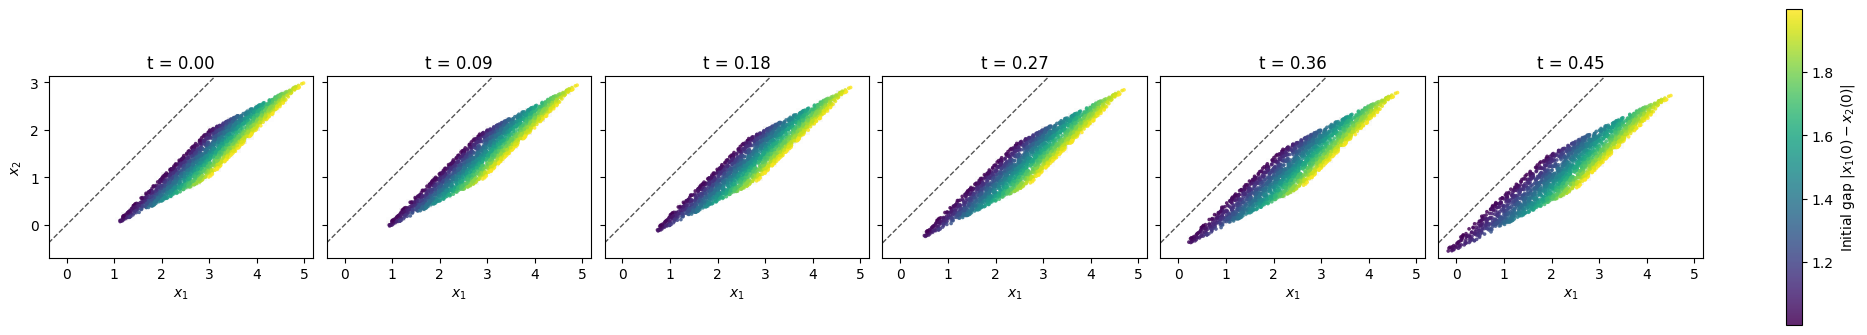

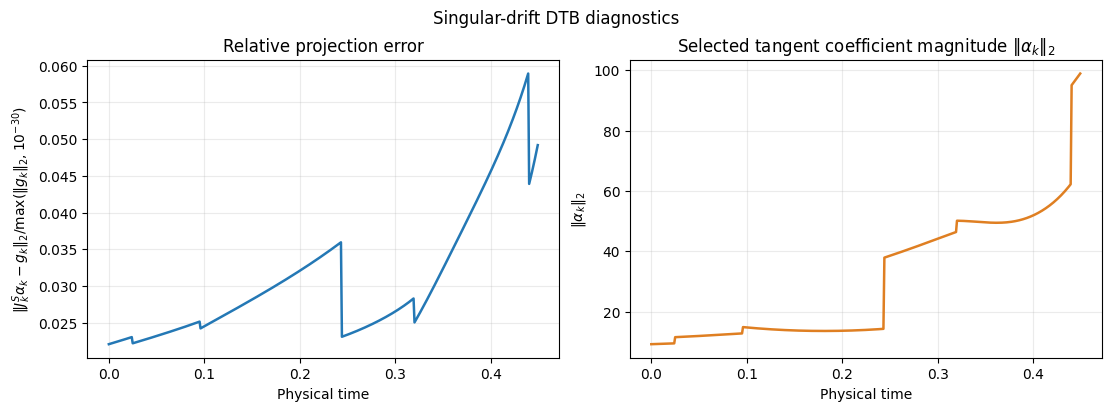

In [4]:
clouds = result['snapshots'].numpy()
x_min, x_max = clouds[..., 0].min(), clouds[..., 0].max()
y_min, y_max = clouds[..., 1].min(), clouds[..., 1].max()
x_pad, y_pad = max(0.1, 0.04*(x_max-x_min)), max(0.1, 0.04*(y_max-y_min))
x_edges = np.linspace(x_min-x_pad, x_max+x_pad, 41)
y_edges = np.linspace(y_min-y_pad, y_max+y_pad, 41)
bin_area = np.diff(x_edges)[:, None] * np.diff(y_edges)[None, :]
densities = [np.histogram2d(q[:, 0], q[:, 1], bins=(x_edges, y_edges))[0]
             / (len(q)*bin_area) for q in clouds]
density_normalization = Normalize(vmin=0, vmax=max(d.max() for d in densities))
# Color follows particle identity: compute it once from the ORIGINAL labels.
initial_points = result['snapshot_labels'].detach().cpu().numpy()
initial_gap = np.abs(initial_points[:, 0] - initial_points[:, 1])
gap_normalization = Normalize(vmin=initial_gap.min(), vmax=initial_gap.max())

fig_snapshots, axes = plt.subplots(1, len(clouds), figsize=(3.1*len(clouds), 3.8),
                                  sharex=True, sharey=True, squeeze=False,
                                  layout='constrained')
for ax, t, density, points in zip(axes.flat, result['snapshot_times'], densities, clouds):
    ax.pcolormesh(x_edges, y_edges, density.T, cmap='Greys', alpha=0.22,
                  norm=density_normalization, shading='auto', rasterized=True)
    colored_points = ax.scatter(points[:, 0], points[:, 1], c=initial_gap,
                                cmap='viridis', norm=gap_normalization,
                                s=7, alpha=0.85, linewidths=0, rasterized=True)
    diagonal = [max(x_edges[0], y_edges[0]), min(x_edges[-1], y_edges[-1])]
    ax.plot(diagonal, diagonal, '--', color='#555555', lw=1)
    ax.set(xlim=(x_edges[0], x_edges[-1]), ylim=(y_edges[0], y_edges[-1]),
           title=f't = {t:.2f}', xlabel='$x_1$')
    ax.set_aspect('equal', adjustable='box')
axes[0, 0].set_ylabel('$x_2$')
fig_snapshots.colorbar(colored_points, ax=axes.ravel().tolist(),
                       label=r'Initial gap $|x_1(0)-x_2(0)|$', shrink=0.85)
plt.show()

fig_diagnostics = plot_tangent_diagnostics(
    result['diagnostic_times'], result['projection_error'],
    result['alpha'].norm(dim=1).numpy())
fig_diagnostics.suptitle('Singular-drift DTB diagnostics')
plt.show()
